In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Project 2 — Toxic Comment Classifier

Fine-tuned DistilBERT on the Civil Comments dataset to classify 
toxic comments. Trained and compared two models to explore the 
precision/recall tradeoff.

## Dataset
- Source: Civil Comments (HuggingFace)
- Training samples: 3,000
- Test samples: 500
- Class distribution: ~95% clean, ~5% toxic

## Models Trained

### Model 1 — Standard Training
| Metric | Score |
|---|---|
| Accuracy | 93.60% |
| F1 | 54.29% |
| Precision | 95.00% |
| Recall | 38.00% |

Best for: Flagging comments for human review (high precision)

### Model 2 — Weighted Loss Training (toxic penalty 10x)
| Metric | Score |
|---|---|
| Accuracy | 86.20% |
| F1 | 51.06% |
| Precision | 39.56% |
| Recall | 72.00% |

Best for: Catching as many toxic comments as possible (high recall)

## Key Learnings
- Class imbalance makes accuracy a misleading metric
- Weighted loss trades precision for recall
- Model cannot learn patterns not present in training data
- Coded language (e.g. "go back to where you came from") 
  requires curated training data to detect
- Production systems need continuous retraining as language evolves

## Tech Stack
- Model: distilbert-base-uncased
- Framework: HuggingFace Transformers + Trainer API
- Metrics: Accuracy, F1, Precision, Recall, Confusion Matrix

In [1]:
!pip install transformers datasets evaluate accelerate -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.9 MB/s eta 0:00:00


In [2]:
import torch
print("GPU available:", torch.cuda.is_available())  # Must print True
print("Transformers imported successfully")

GPU available: True
Transformers imported successfully


In [4]:
from datasets import load_dataset

dataset = load_dataset("civil_comments")
print(dataset)
print("\nSample entry:")
print(dataset["train"][0])

DatasetDict({
    train: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 1804874
    })
    validation: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 97320
    })
    test: Dataset({
        features: ['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult', 'identity_attack', 'sexual_explicit'],
        num_rows: 97320
    })
})

Sample entry:
{'text': "This is so cool. It's like, 'would you want your mother to read this??' Really great idea, well done!", 'toxicity': 0.0, 'severe_toxicity': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_attack': 0.0, 'sexual_explicit': 0.0}


In [5]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

def preprocess(examples):
    # Convert toxicity score to binary label
    examples["labels"] = [1 if t >= 0.5 else 0 for t in examples["toxicity"]]
    # Tokenize the text
    tokens = tokenizer(
        examples["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )
    tokens["labels"] = examples["labels"]
    return tokens

# Use small subset to keep training fast
small_train = dataset["train"].select(range(3000))
small_test = dataset["test"].select(range(500))

tokenized_train = small_train.map(preprocess, batched=True)
tokenized_test = small_test.map(preprocess, batched=True)

print("Train size:", len(tokenized_train))
print("Test size:", len(tokenized_test))

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/3000 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

Train size: 3000
Test size: 500


In [6]:
# Run this before the preprocess function
sample_text = "You are an idiot and should be banned"

tokens = tokenizer(sample_text, truncation=True, padding="max_length", max_length=128)

print("Input IDs:", tokens["input_ids"][:20], "...")
print("Attention mask:", tokens["attention_mask"][:20], "...")
print("Decoded back:", tokenizer.decode(tokens["input_ids"]))
print("Token count:", sum(tokens["attention_mask"]))  # actual tokens, not padding

Input IDs: [101, 2017, 2024, 2019, 10041, 1998, 2323, 2022, 7917, 102, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0] ...
Decoded back: [CLS] you are an idiot and should be banned [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
Token count: 10


In [7]:
for length in [32, 64, 128, 256]:
    tokens = tokenizer(sample_text, truncation=True, 
                      padding="max_length", max_length=length)
    print(f"max_length={length}: real tokens={sum(tokens['attention_mask'])}, "
          f"padding={length - sum(tokens['attention_mask'])}")

max_length=32: real tokens=10, padding=22
max_length=64: real tokens=10, padding=54
max_length=128: real tokens=10, padding=118
max_length=256: real tokens=10, padding=246


In [8]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)
print("Model loaded")
print("Parameters:", sum(p.numel() for p in model.parameters()), "total")
print("Total parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
print("Trainable parameters:", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded
Parameters: 66955010 total
Total parameters: 66,955,010
Trainable parameters: 66,955,010


In [10]:
print("Model loaded successfully")
print("Total parameters:", f"{sum(p.numel() for p in model.parameters()):,}")
print("Trainable parameters:", f"{sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print("Model type:", type(model).__name__)

Model loaded successfully
Total parameters: 66,955,010
Trainable parameters: 66,955,010
Model type: DistilBertForSequenceClassification


In [11]:
from transformers import AutoModel

base_model = AutoModel.from_pretrained("distilbert-base-uncased")
print("BASE MODEL layers:")
for name, param in base_model.named_parameters():
    print(name)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BASE MODEL layers:
embeddings.word_embeddings.weight
embeddings.position_embeddings.weight
embeddings.LayerNorm.weight
embeddings.LayerNorm.bias
transformer.layer.0.attention.q_lin.weight
transformer.layer.0.attention.q_lin.bias
transformer.layer.0.attention.k_lin.weight
transformer.layer.0.attention.k_lin.bias
transformer.layer.0.attention.v_lin.weight
transformer.layer.0.attention.v_lin.bias
transformer.layer.0.attention.out_lin.weight
transformer.layer.0.attention.out_lin.bias
transformer.layer.0.sa_layer_norm.weight
transformer.layer.0.sa_layer_norm.bias
transformer.layer.0.ffn.lin1.weight
transformer.layer.0.ffn.lin1.bias
transformer.layer.0.ffn.lin2.weight
transformer.layer.0.ffn.lin2.bias
transformer.layer.0.output_layer_norm.weight
transformer.layer.0.output_layer_norm.bias
transformer.layer.1.attention.q_lin.weight
transformer.layer.1.attention.q_lin.bias
transformer.layer.1.attention.k_lin.weight
transformer.layer.1.attention.k_lin.bias
transformer.layer.1.attention.v_lin.wei

In [12]:
print("\nCLASSIFICATION MODEL layers:")
for name, param in model.named_parameters():
    print(name)




CLASSIFICATION MODEL layers:
distilbert.embeddings.word_embeddings.weight
distilbert.embeddings.position_embeddings.weight
distilbert.embeddings.LayerNorm.weight
distilbert.embeddings.LayerNorm.bias
distilbert.transformer.layer.0.attention.q_lin.weight
distilbert.transformer.layer.0.attention.q_lin.bias
distilbert.transformer.layer.0.attention.k_lin.weight
distilbert.transformer.layer.0.attention.k_lin.bias
distilbert.transformer.layer.0.attention.v_lin.weight
distilbert.transformer.layer.0.attention.v_lin.bias
distilbert.transformer.layer.0.attention.out_lin.weight
distilbert.transformer.layer.0.attention.out_lin.bias
distilbert.transformer.layer.0.sa_layer_norm.weight
distilbert.transformer.layer.0.sa_layer_norm.bias
distilbert.transformer.layer.0.ffn.lin1.weight
distilbert.transformer.layer.0.ffn.lin1.bias
distilbert.transformer.layer.0.ffn.lin2.weight
distilbert.transformer.layer.0.ffn.lin2.bias
distilbert.transformer.layer.0.output_layer_norm.weight
distilbert.transformer.layer.0

In [13]:
import evaluate
import numpy as np

accuracy_metric = evaluate.load("accuracy")
f1_metric = evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    accuracy = accuracy_metric.compute(
        predictions=predictions, references=labels)
    f1 = f1_metric.compute(
        predictions=predictions, references=labels, average="binary")
    
    return {**accuracy, **f1}

print("Metrics set up successfully")

Metrics set up successfully


In [14]:
import torch
import torch.nn.functional as F

# Simulate what model outputs look like
raw_logits = torch.tensor([
    [-2.1,  3.4],   # strongly toxic
    [ 2.8, -1.2],   # strongly clean  
    [-0.1,  0.2],   # uncertain
    [-3.5,  4.1],   # very strongly toxic
])

# Convert to probabilities using softmax
probabilities = F.softmax(raw_logits, dim=-1)

# Get final predictions
predictions = torch.argmax(raw_logits, dim=-1)

print(f"{'Logits':<25} {'Probabilities':<30} {'Prediction'}")
print("-" * 70)
for logit, prob, pred in zip(raw_logits, probabilities, predictions):
    label = "TOXIC" if pred == 1 else "CLEAN"
    print(f"{str(logit.tolist()):<25} {str([f'{p:.2f}' for p in prob.tolist()]):<30} {label}")


Logits                    Probabilities                  Prediction
----------------------------------------------------------------------
[-2.0999999046325684, 3.4000000953674316] ['0.00', '1.00']               TOXIC
[2.799999952316284, -1.2000000476837158] ['0.98', '0.02']               CLEAN
[-0.10000000149011612, 0.20000000298023224] ['0.43', '0.57']               TOXIC
[-3.5, 4.099999904632568] ['0.00', '1.00']               TOXIC


In [15]:
# Check class distribution in your dataset
toxic_count = sum(1 for x in small_train if x["toxicity"] >= 0.5)
clean_count = len(small_train) - toxic_count

print(f"Training set composition:")
print(f"Toxic comments:  {toxic_count} ({toxic_count/len(small_train)*100:.1f}%)")
print(f"Clean comments:  {clean_count} ({clean_count/len(small_train)*100:.1f}%)")

# Simulate a dumb model that always predicts CLEAN
dummy_predictions = [0] * 500  # always predicts clean
true_labels = [1 if small_test[i]["toxicity"] >= 0.5 else 0 for i in range(500)]

dummy_accuracy = accuracy_metric.compute(
    predictions=dummy_predictions, references=true_labels)
dummy_f1 = f1_metric.compute(
    predictions=dummy_predictions, references=true_labels, average="binary")

print(f"\nDummy model (always predicts CLEAN):")
print(f"Accuracy: {dummy_accuracy['accuracy']:.2%}")
print(f"F1 Score: {dummy_f1['f1']:.2%}")
print(f"\nConclusion: High accuracy but catches ZERO toxic comments")


Training set composition:
Toxic comments:  139 (4.6%)
Clean comments:  2861 (95.4%)

Dummy model (always predicts CLEAN):
Accuracy: 90.00%
F1 Score: 0.00%

Conclusion: High accuracy but catches ZERO toxic comments


In [17]:
def detailed_metrics(predictions, labels):
    tp = sum((p == 1 and l == 1) for p, l in zip(predictions, labels))
    fp = sum((p == 1 and l == 0) for p, l in zip(predictions, labels))
    fn = sum((p == 0 and l == 1) for p, l in zip(predictions, labels))
    tn = sum((p == 0 and l == 0) for p, l in zip(predictions, labels))
    
    total = len(labels)
    
    print("=" * 45)
    print("CONFUSION MATRIX")
    print("=" * 45)
    print(f"                  Predicted")
    print(f"                  CLEAN    TOXIC")
    print(f"Actual  CLEAN  |  {tn:<8} {fp:<8}|")
    print(f"        TOXIC  |  {fn:<8} {tp:<8}|")
    print("=" * 45)
    print(f"\nTrue Positives  (caught toxic):      {tp}")
    print(f"False Positives (wrongly flagged):   {fp}")
    print(f"False Negatives (missed toxic):      {fn}")
    print(f"True Negatives  (correctly clean):   {tn}")
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"\nPrecision: {precision:.2%}  (of flagged comments, how many were truly toxic)")
    print(f"Recall:    {recall:.2%}  (of all toxic comments, how many did we catch)")

# Test with dummy model first
print("DUMMY MODEL (always predicts CLEAN):")
detailed_metrics(dummy_predictions, true_labels)

DUMMY MODEL (always predicts CLEAN):
CONFUSION MATRIX
                  Predicted
                  CLEAN    TOXIC
Actual  CLEAN  |  450      0       |
        TOXIC  |  50       0       |

True Positives  (caught toxic):      0
False Positives (wrongly flagged):   0
False Negatives (missed toxic):      50
True Negatives  (correctly clean):   450

Precision: 0.00%  (of flagged comments, how many were truly toxic)
Recall:    0.00%  (of all toxic comments, how many did we catch)


In [18]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    
    accuracy = accuracy_metric.compute(
        predictions=predictions, references=labels)
    f1 = f1_metric.compute(
        predictions=predictions, references=labels, average="binary")
    
    # Confusion matrix components
    tp = int(sum((p == 1 and l == 1) for p, l in zip(predictions, labels)))
    fp = int(sum((p == 1 and l == 0) for p, l in zip(predictions, labels)))
    fn = int(sum((p == 0 and l == 1) for p, l in zip(predictions, labels)))
    tn = int(sum((p == 0 and l == 0) for p, l in zip(predictions, labels)))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    print(f"\n📊 Epoch Results:")
    print(f"   Accuracy:  {accuracy['accuracy']:.2%}")
    print(f"   F1:        {f1['f1']:.2%}")
    print(f"   Precision: {precision:.2%}")
    print(f"   Recall:    {recall:.2%}")
    print(f"   TP={tp} FP={fp} FN={fn} TN={tn}")
    
    return {
        **accuracy,
        **f1,
        "precision": precision,
        "recall": recall
    }

print("Enhanced metrics ready")

Enhanced metrics ready


In [20]:
from transformers import TrainingArguments, Trainer

training_args = TrainingArguments(
    output_dir="toxic-classifier",
    eval_strategy="epoch",          # renamed from evaluation_strategy
    save_strategy="epoch",
    num_train_epochs=2,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    load_best_model_at_end=True,
    logging_steps=50,
    warmup_steps=100,
    weight_decay=0.01,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

trainer.train()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.899300,0.721395,0.900000,0.000000,0,0.000000
2,0.298231,0.518634,0.910000,0.181818,1.000000,0.100000



📊 Epoch Results:
   Accuracy:  90.00%
   F1:        0.00%
   Precision: 0.00%
   Recall:    0.00%
   TP=0 FP=0 FN=50 TN=450


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



📊 Epoch Results:
   Accuracy:  91.00%
   F1:        18.18%
   Precision: 100.00%
   Recall:    10.00%
   TP=5 FP=0 FN=45 TN=450


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=188, training_loss=0.4680214841315087, metrics={'train_runtime': 47.183, 'train_samples_per_second': 127.164, 'train_steps_per_second': 3.984, 'total_flos': 198701097984000.0, 'train_loss': 0.4680214841315087, 'epoch': 2.0})

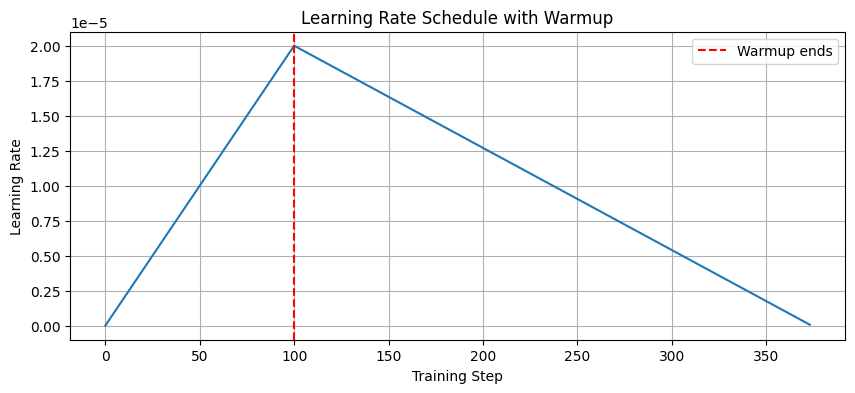

Total training steps: 374
Warmup steps: 100 (26.7% of training)


In [21]:
import matplotlib.pyplot as plt
import numpy as np

total_steps = (3000 // 16) * 2  # samples/batch_size * epochs
warmup_steps = 100

def get_lr(step, warmup_steps, total_steps, max_lr=2e-5):
    if step < warmup_steps:
        return max_lr * (step / warmup_steps)  # ramp up
    else:
        # linear decay after warmup
        progress = (step - warmup_steps) / (total_steps - warmup_steps)
        return max_lr * (1 - progress)

steps = list(range(total_steps))
lrs = [get_lr(s, warmup_steps, total_steps) for s in steps]

plt.figure(figsize=(10, 4))
plt.plot(steps, lrs)
plt.axvline(x=warmup_steps, color='r', linestyle='--', label='Warmup ends')
plt.xlabel("Training Step")
plt.ylabel("Learning Rate")
plt.title("Learning Rate Schedule with Warmup")
plt.legend()
plt.grid(True)
plt.show()

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {warmup_steps} ({warmup_steps/total_steps*100:.1f}% of training)")

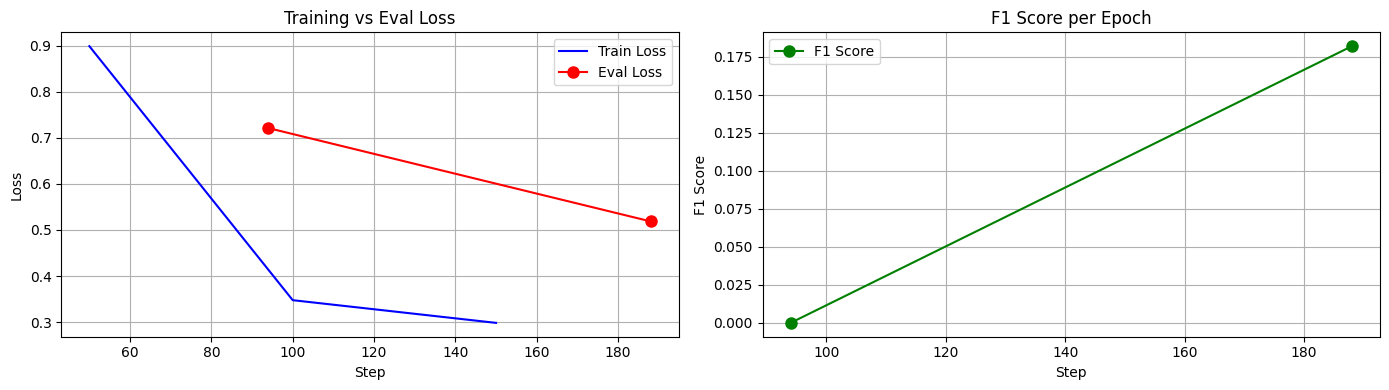

Best F1: 18.18% at step 188


In [22]:
import matplotlib.pyplot as plt

# Extract training history
log_history = trainer.state.log_history

# Separate train loss and eval metrics
train_steps = [x["step"] for x in log_history if "loss" in x]
train_losses = [x["loss"] for x in log_history if "loss" in x]

eval_steps = [x["step"] for x in log_history if "eval_loss" in x]
eval_losses = [x["eval_loss"] for x in log_history if "eval_loss" in x]
eval_f1 = [x["eval_f1"] for x in log_history if "eval_f1" in x]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

# Loss curve
ax1.plot(train_steps, train_losses, label="Train Loss", color="blue")
ax1.plot(eval_steps, eval_losses, label="Eval Loss", 
         color="red", marker="o", markersize=8)
ax1.set_xlabel("Step")
ax1.set_ylabel("Loss")
ax1.set_title("Training vs Eval Loss")
ax1.legend()
ax1.grid(True)

# F1 curve
ax2.plot(eval_steps, eval_f1, label="F1 Score", 
         color="green", marker="o", markersize=8)
ax2.set_xlabel("Step")
ax2.set_ylabel("F1 Score")
ax2.set_title("F1 Score per Epoch")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Best F1: {max(eval_f1):.2%} at step {eval_steps[eval_f1.index(max(eval_f1))]}")

In [24]:
training_args_32 = TrainingArguments(
    output_dir="toxic-classifier-bs32",
    eval_strategy="epoch",          # fixed
    num_train_epochs=2,
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    logging_steps=25,
)

trainer_32 = Trainer(
    model=model,
    args=training_args_32,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

trainer_32.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.249370,0.478925,0.934000,0.521739,0.947368,0.360000
2,0.088228,0.514240,0.936000,0.542857,0.950000,0.380000



📊 Epoch Results:
   Accuracy:  93.40%
   F1:        52.17%
   Precision: 94.74%
   Recall:    36.00%
   TP=18 FP=1 FN=32 TN=449


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



📊 Epoch Results:
   Accuracy:  93.60%
   F1:        54.29%
   Precision: 95.00%
   Recall:    38.00%
   TP=19 FP=1 FN=31 TN=449


TrainOutput(global_step=94, training_loss=0.15845736036909389, metrics={'train_runtime': 39.5842, 'train_samples_per_second': 151.576, 'train_steps_per_second': 2.375, 'total_flos': 198701097984000.0, 'train_loss': 0.15845736036909389, 'epoch': 2.0})

In [25]:
# Overall evaluation
results = trainer.evaluate()
print("=" * 40)
print("FINAL MODEL RESULTS")
print("=" * 40)
print(f"Accuracy:  {results['eval_accuracy']:.2%}")
print(f"F1 Score:  {results['eval_f1']:.2%}")
print(f"Precision: {results['eval_precision']:.2%}")
print(f"Recall:    {results['eval_recall']:.2%}")
print(f"Eval Loss: {results['eval_loss']:.4f}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



📊 Epoch Results:
   Accuracy:  93.60%
   F1:        54.29%
   Precision: 95.00%
   Recall:    38.00%
   TP=19 FP=1 FN=31 TN=449
FINAL MODEL RESULTS
Accuracy:  93.60%
F1 Score:  54.29%
Precision: 95.00%
Recall:    38.00%
Eval Loss: 0.5142


In [ ]:
print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 70)

tricky_comments = [
    "Go back to where you came from",
    "I'm sure someone like you would think that",
    "That's a very brave opinion for someone so wrong",
    "You are an idiot and should be banned",
    "I disagree with your point but respect your opinion",
]

for threshold in [0.5, 0.4, 0.3, 0.2]:
    print(f"\n--- Threshold: {threshold} ---")
    for comment in tricky_comments:
        label, prob = predict_with_threshold(comment, threshold)
        print(f"{label} ({prob:.2%}) — {comment[:50]}")

In [26]:
from transformers import pipeline
import torch

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

test_comments = [
    # Obvious toxic
    "You are an idiot and should be banned",
    "Go back to where you came from",
    # Subtle toxic
    "I'm sure someone like you would think that",
    "That's a very brave opinion for someone so wrong",
    # Obvious clean
    "I disagree with your point but respect your opinion",
    "Great explanation, thanks for sharing",
    # Tricky edge cases
    "This is sick",                        # slang for good
    "I could care less about your opinion", # grammatically wrong but common
    "Not bad at all",                       # double negative = positive
    "You must be joking",                   # could be toxic or not
]

print(f"\n{'Comment':<50} {'Label':<12} {'Confidence'}")
print("-" * 75)
for comment in test_comments:
    result = classifier(comment)[0]
    label = "🚨 TOXIC" if result['label'] == 'LABEL_1' else "✅ CLEAN"
    print(f"{comment[:49]:<50} {label:<12} {result['score']:.2%}")


Comment                                            Label        Confidence
---------------------------------------------------------------------------
You are an idiot and should be banned              🚨 TOXIC      91.50%
Go back to where you came from                     ✅ CLEAN      99.55%
I'm sure someone like you would think that         ✅ CLEAN      99.66%
That's a very brave opinion for someone so wrong   ✅ CLEAN      99.54%
I disagree with your point but respect your opini  ✅ CLEAN      99.53%
Great explanation, thanks for sharing              ✅ CLEAN      99.68%
This is sick                                       ✅ CLEAN      86.41%
I could care less about your opinion               ✅ CLEAN      99.57%
Not bad at all                                     ✅ CLEAN      99.43%
You must be joking                                 ✅ CLEAN      99.09%


In [27]:
print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 70)

tricky_comments = [
    "Go back to where you came from",
    "I'm sure someone like you would think that",
    "That's a very brave opinion for someone so wrong",
    "You are an idiot and should be banned",
    "I disagree with your point but respect your opinion",
]

for threshold in [0.5, 0.4, 0.3, 0.2]:
    print(f"\n--- Threshold: {threshold} ---")
    for comment in tricky_comments:
        label, prob = predict_with_threshold(comment, threshold)
        print(f"{label} ({prob:.2%}) — {comment[:50]}")

THRESHOLD SENSITIVITY ANALYSIS

--- Threshold: 0.5 ---


NameError: name 'predict_with_threshold' is not defined

In [28]:
print("\nERROR ANALYSIS — First 200 test samples")
print("=" * 70)

wrong = []
correct = []

for i in range(200):
    text = small_test[i]["text"]
    true_label = 1 if small_test[i]["toxicity"] >= 0.5 else 0
    
    result = classifier(text[:512])[0]
    predicted = 1 if result['label'] == 'LABEL_1' else 0
    confidence = result['score']
    
    entry = {
        "text": text[:80],
        "true": "TOXIC" if true_label == 1 else "CLEAN",
        "predicted": "TOXIC" if predicted == 1 else "CLEAN",
        "confidence": confidence,
        "correct": predicted == true_label
    }
    
    if predicted != true_label:
        wrong.append(entry)
    else:
        correct.append(entry)

print(f"Correct:   {len(correct)}/200 ({len(correct)/200:.0%})")
print(f"Wrong:     {len(wrong)}/200 ({len(wrong)/200:.0%})")

print(f"\n--- MISTAKES ---")
for w in wrong[:8]:
    print(f"\nText:      {w['text']}")
    print(f"True:      {w['true']}  |  Predicted: {w['predicted']}  |  Confidence: {w['confidence']:.2%}")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



ERROR ANALYSIS — First 200 test samples
Correct:   190/200 (95%)
Wrong:     10/200 (5%)

--- MISTAKES ---

Text:      Our oils read;  President IS taking different tactics to deal with a corrupt mal
True:      TOXIC  |  Predicted: CLEAN  |  Confidence: 69.06%

Text:      Between racist Eastman and 'Slappy' Wilson the Wasilla delegation is an embarass
True:      TOXIC  |  Predicted: CLEAN  |  Confidence: 98.80%

Text:      Well here we go again.  Let's continue to subsidize the cost of power, costs tha
True:      TOXIC  |  Predicted: CLEAN  |  Confidence: 98.48%

Text:      An "abject lesson" is a lesson that is painful or humiliating.  "Object" on the 
True:      TOXIC  |  Predicted: CLEAN  |  Confidence: 98.76%

Text:      Somebody needs to dig up the Peterson's back yard!  What other evil deeds did Mo
True:      TOXIC  |  Predicted: CLEAN  |  Confidence: 91.90%

Text:      Only in America can you get 25 likes for admitting you are pathetic. But serious
True:      TOXIC  |  Predicted

In [29]:
import torch
import torch.nn.functional as F

def predict_with_threshold(text, threshold=0.5):
    inputs = tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128
    )
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    probs = F.softmax(outputs.logits, dim=-1)
    toxic_prob = probs[0][1].item()
    
    if toxic_prob >= threshold:
        label = "🚨 TOXIC"
    else:
        label = "✅ CLEAN"
    
    return label, toxic_prob

# Test same comment with different thresholds
test = "I'm sure someone like you would think that"
print(f"Comment: {test}\n")

for threshold in [0.3, 0.5, 0.7, 0.9]:
    label, prob = predict_with_threshold(test, threshold)
    print(f"Threshold {threshold}: {label} (toxic probability: {prob:.2%})")

Comment: I'm sure someone like you would think that



RuntimeError: Expected all tensors to be on the same device, but got index is on cpu, different from other tensors on cuda:0 (when checking argument in method wrapper_CUDA__index_select)

In [30]:
import torch
import torch.nn.functional as F

# Detect which device model is on
device = next(model.parameters()).device
print(f"Model is on: {device}")

def predict_with_threshold(text, threshold=0.5):
    inputs = tokenizer(
        text, return_tensors="pt",
        truncation=True, max_length=128
    )
    
    # Move inputs to same device as model
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    probs = F.softmax(outputs.logits, dim=-1)
    toxic_prob = probs[0][1].item()
    
    if toxic_prob >= threshold:
        label = "🚨 TOXIC"
    else:
        label = "✅ CLEAN"
    
    return label, toxic_prob

print("predict_with_threshold defined successfully")

Model is on: cuda:0
predict_with_threshold defined successfully


In [31]:
print("THRESHOLD SENSITIVITY ANALYSIS")
print("=" * 70)

tricky_comments = [
    "Go back to where you came from",
    "I'm sure someone like you would think that",
    "That's a very brave opinion for someone so wrong",
    "You are an idiot and should be banned",
    "I disagree with your point but respect your opinion",
]

for threshold in [0.5, 0.4, 0.3, 0.2]:
    print(f"\n--- Threshold: {threshold} ---")
    for comment in tricky_comments:
        label, prob = predict_with_threshold(comment, threshold)
        print(f"{label} ({prob:.2%}) — {comment[:50]}")


THRESHOLD SENSITIVITY ANALYSIS

--- Threshold: 0.5 ---
✅ CLEAN (0.45%) — Go back to where you came from
✅ CLEAN (0.34%) — I'm sure someone like you would think that
✅ CLEAN (0.46%) — That's a very brave opinion for someone so wrong
🚨 TOXIC (91.50%) — You are an idiot and should be banned
✅ CLEAN (0.47%) — I disagree with your point but respect your opinio

--- Threshold: 0.4 ---
✅ CLEAN (0.45%) — Go back to where you came from
✅ CLEAN (0.34%) — I'm sure someone like you would think that
✅ CLEAN (0.46%) — That's a very brave opinion for someone so wrong
🚨 TOXIC (91.50%) — You are an idiot and should be banned
✅ CLEAN (0.47%) — I disagree with your point but respect your opinio

--- Threshold: 0.3 ---
✅ CLEAN (0.45%) — Go back to where you came from
✅ CLEAN (0.34%) — I'm sure someone like you would think that
✅ CLEAN (0.46%) — That's a very brave opinion for someone so wrong
🚨 TOXIC (91.50%) — You are an idiot and should be banned
✅ CLEAN (0.47%) — I disagree with your point but respect 

In [32]:
# Load base sentiment model
base_classifier = pipeline(
    "text-classification",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

tricky_comments = [
    "You are an idiot",
    "Go back to where you came from",
    "I disagree but respect your view",
    "This is absolutely terrible behavior",
    "Not bad at all",
    "I'm sure someone like you would think that",
]

print(f"{'Comment':<45} {'Base Model':<20} {'Fine-tuned':<15}")
print("-" * 80)

for comment in tricky_comments:
    base_result = base_classifier(comment)[0]
    base_label = base_result['label']
    
    ft_result = classifier(comment)[0]
    ft_label = "TOXIC" if ft_result['label'] == 'LABEL_1' else "CLEAN"
    
    print(f"{comment[:44]:<45} {base_label:<20} {ft_label:<15}")

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Comment                                       Base Model           Fine-tuned     
--------------------------------------------------------------------------------
You are an idiot                              NEGATIVE             TOXIC          
Go back to where you came from                POSITIVE             CLEAN          
I disagree but respect your view              POSITIVE             CLEAN          
This is absolutely terrible behavior          NEGATIVE             CLEAN          
Not bad at all                                POSITIVE             CLEAN          
I'm sure someone like you would think that    POSITIVE             CLEAN          


In [33]:
custom_comments = [
    # Add your own test cases here
    "Your distributed systems design is fundamentally broken",
    "I respectfully disagree with your architecture choice",
    "Only an idiot would design a system like this",
    "This PR needs significant improvements before merging",
    "You clearly have no idea what you are talking about",
    "Interesting approach, have you considered using Kafka instead?",
]

print("CUSTOM COMMENT TESTING")
print("=" * 60)
for comment in custom_comments:
    label, prob = predict_with_threshold(comment, threshold=0.5)
    print(f"{label} ({prob:.2%}) — {comment}")

CUSTOM COMMENT TESTING
✅ CLEAN (0.50%) — Your distributed systems design is fundamentally broken
✅ CLEAN (0.43%) — I respectfully disagree with your architecture choice
🚨 TOXIC (89.58%) — Only an idiot would design a system like this
✅ CLEAN (0.51%) — This PR needs significant improvements before merging
✅ CLEAN (0.39%) — You clearly have no idea what you are talking about
✅ CLEAN (0.37%) — Interesting approach, have you considered using Kafka instead?


In [35]:
results = trainer.evaluate()
print("=" * 40)
print("FINAL MODEL RESULTS")
print("=" * 40)
print(f"Accuracy:  {results['eval_accuracy']:.2%}")
print(f"F1 Score:  {results['eval_f1']:.2%}")
print(f"Precision: {results['eval_precision']:.2%}")
print(f"Recall:    {results['eval_recall']:.2%}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



📊 Epoch Results:
   Accuracy:  93.60%
   F1:        54.29%
   Precision: 95.00%
   Recall:    38.00%
   TP=19 FP=1 FN=31 TN=449
FINAL MODEL RESULTS
Accuracy:  93.60%
F1 Score:  54.29%
Precision: 95.00%
Recall:    38.00%


In [36]:
test_comments = [
    "You are an idiot and should be banned",
    "Go back to where you came from",
    "I disagree with your point but respect your opinion",
    "Great explanation, thanks for sharing",
    "That's a very brave opinion for someone so wrong",
    "This is sick",
]

print(f"{'Comment':<50} {'Label':<12} {'Confidence'}")
print("-" * 75)
for comment in test_comments:
    label, prob = predict_with_threshold(comment, threshold=0.2)
    print(f"{comment[:49]:<50} {label:<12} {prob:.2%}")

Comment                                            Label        Confidence
---------------------------------------------------------------------------
You are an idiot and should be banned              🚨 TOXIC      91.50%
Go back to where you came from                     ✅ CLEAN      0.45%
I disagree with your point but respect your opini  ✅ CLEAN      0.47%
Great explanation, thanks for sharing              ✅ CLEAN      0.32%
That's a very brave opinion for someone so wrong   ✅ CLEAN      0.46%
This is sick                                       ✅ CLEAN      13.59%


In [37]:
from torch import nn

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        
        # Penalize missing toxic comments 10x more
        class_weights = torch.tensor([1.0, 10.0]).to(logits.device)
        loss_fn = nn.CrossEntropyLoss(weight=class_weights)
        loss = loss_fn(logits, labels)
        
        return (loss, outputs) if return_outputs else loss

# Reset model to fresh pretrained weights
from transformers import AutoModelForSequenceClassification
model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)

from transformers import TrainingArguments
training_args = TrainingArguments(
    output_dir="toxic-classifier-weighted",
    eval_strategy="epoch",
    save_strategy="epoch",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    learning_rate=2e-5,
    load_best_model_at_end=True,
    logging_steps=50,
    warmup_steps=100,
    weight_decay=0.01,
)

weighted_trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

weighted_trainer.train()

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, 

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.666196,0.897700,0.900000,0.000000,0,0.000000
2,0.441275,0.430742,0.862000,0.510638,0.395604,0.720000
3,0.248349,0.867203,0.934000,0.602410,0.757576,0.500000



📊 Epoch Results:
   Accuracy:  90.00%
   F1:        0.00%
   Precision: 0.00%
   Recall:    0.00%
   TP=0 FP=0 FN=50 TN=450


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



📊 Epoch Results:
   Accuracy:  93.40%
   F1:        60.24%
   Precision: 75.76%
   Recall:    50.00%
   TP=25 FP=8 FN=25 TN=442


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=282, training_loss=0.4454535203622588, metrics={'train_runtime': 74.8782, 'train_samples_per_second': 120.195, 'train_steps_per_second': 3.766, 'total_flos': 298051646976000.0, 'train_loss': 0.4454535203622588, 'epoch': 3.0})

In [38]:
# Update device after reloading model
device = next(model.parameters()).device

test_comments = [
    "You are an idiot and should be banned",
    "Go back to where you came from",
    "I disagree with your point but respect your opinion",
    "Great explanation, thanks for sharing",
    "That's a very brave opinion for someone so wrong",
    "This is sick",
]

print(f"{'Comment':<50} {'Label':<12} {'Confidence'}")
print("-" * 75)
for comment in test_comments:
    label, prob = predict_with_threshold(comment, threshold=0.3)
    print(f"{comment[:49]:<50} {label:<12} {prob:.2%}")

Comment                                            Label        Confidence
---------------------------------------------------------------------------
You are an idiot and should be banned              🚨 TOXIC      84.82%
Go back to where you came from                     ✅ CLEAN      7.32%
I disagree with your point but respect your opini  ✅ CLEAN      3.93%
Great explanation, thanks for sharing              ✅ CLEAN      2.82%
That's a very brave opinion for someone so wrong   ✅ CLEAN      15.35%
This is sick                                       🚨 TOXIC      44.59%


In [39]:
# Search training data for similar phrases
found = []
for i in range(len(small_train)):
    text = small_train[i]["text"].lower()
    if "go back" in text or "where you came from" in text:
        found.append({
            "text": small_train[i]["text"][:100],
            "toxicity": small_train[i]["toxicity"]
        })

print(f"Found {len(found)} similar examples in training data\n")
for f in found[:5]:
    print(f"Toxicity: {f['toxicity']:.2f} — {f['text']}")

Found 9 similar examples in training data

Toxicity: 0.00 — Tried this out on another post.  Having to rate three other comments and then my own - is the lead d
Toxicity: 0.00 — let me some up the heavy vibers feelings:

GO BACK TO CALIFORNIA.
Toxicity: 0.00 — Good question, Jackie! How do these yokels make their money? Well, LaVoy Finicum just had his foster
Toxicity: 0.00 — Always remember, we are at risk of doom no matter where we live on this planet; nuclear holocaust, a
Toxicity: 0.60 — I've gone there for 30 years and was born and raised in Portland. I would love to know how many peop


In [40]:
results = weighted_trainer.evaluate()
print("=" * 45)
print("WEIGHTED MODEL — FINAL RESULTS")
print("=" * 45)
print(f"Accuracy:  {results['eval_accuracy']:.2%}")
print(f"F1 Score:  {results['eval_f1']:.2%}")
print(f"Precision: {results['eval_precision']:.2%}")
print(f"Recall:    {results['eval_recall']:.2%}")

print("\nIMPROVEMENT vs ORIGINAL MODEL:")
print(f"F1:     54.29% → {results['eval_f1']:.2%}")
print(f"Recall: 38.00% → {results['eval_recall']:.2%}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]



📊 Epoch Results:
   Accuracy:  86.20%
   F1:        51.06%
   Precision: 39.56%
   Recall:    72.00%
   TP=36 FP=55 FN=14 TN=395
WEIGHTED MODEL — FINAL RESULTS
Accuracy:  86.20%
F1 Score:  51.06%
Precision: 39.56%
Recall:    72.00%

IMPROVEMENT vs ORIGINAL MODEL:
F1:     54.29% → 51.06%
Recall: 38.00% → 72.00%
